# Intervals on the Number Line

**This notebook teaches intervals from scratch.**

Very often we care not about a single number but about a whole **range** of numbers: a healthy blood-pressure range, a safe dose, an age group, the values a measurement is allowed to take. An **interval** is the mathematical name for such a range — it is the set of **all** real numbers lying between two endpoints. This notebook covers how to write intervals, the important difference between *including* and *excluding* an endpoint, ranges that run to infinity, and how to combine intervals.

## Learning objectives

- Read and write interval notation $[a,b], (a,b), [a,b), (a,b]$.
- Distinguish a **closed** endpoint (included) from an **open** endpoint (excluded).
- Write **unbounded** intervals using $\pm\infty$.
- Combine intervals with **union** and **intersection**, and test membership.

## Background

An **interval** is the set of every real number between a lower endpoint $a$ and an upper endpoint $b$. Whether the endpoints themselves belong to the set is shown by the bracket: a **square bracket** includes the endpoint, a **parenthesis** excludes it.

$$[a,b] = \{x : a \le x \le b\}\ (\text{both ends in}), \quad (a,b) = \{x : a < x < b\}\ (\text{both ends out}), \quad [a,b) = \{x : a \le x < b\}\ (\text{left in, right out}).$$

The distinction matters whenever a boundary value is itself allowed or not — "greater than 18" (18 excluded) is different from "18 or older" (18 included). An endpoint can also be infinite: $[a, \infty) = \{x : x \ge a\}$ runs forever to the right. Infinity is never actually reached, so it always takes a parenthesis. Finally, the **same** range can be written three equivalent ways — as an inequality, in set-builder notation, or in interval notation.

## This notebook covers

1. An interval as a set of reals.
2. Closed vs open endpoints.
3. Unbounded intervals.
4. Three equivalent notations.
5. Combining intervals (union and intersection).
6. An "in range" test.

**Prerequisites:** `U1-2_Sets-3_NumberSystems`

**Dataset:** none — endpoints are chosen by hand; a lab reference range is the running example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

## 1. An interval as a set of reals

The closed interval $[a, b]$ is every real number from $a$ to $b$, with both endpoints **included**. Unlike a set of separate items, an interval is a *continuous* stretch — there are infinitely many numbers in it, with no gaps. We picture it as a shaded segment of the number line.

*(The drawing code is just plotting — focus on the shaded stretch and its two endpoints.)*

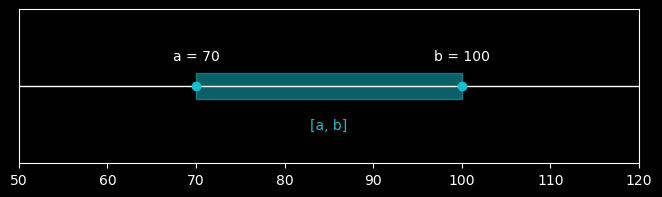

In [2]:
a = 70    # lower endpoint
b = 100   # upper endpoint

# --- graphics: shade [a, b] on a number line (mechanics only) ---
fig, ax = plt.subplots(figsize=(8, 2))
ax.axhline(0, color="white", lw=1)
x = np.linspace(a, b, 100)
ax.fill_between(x, -0.15, 0.15, color="tab:cyan", alpha=0.5)
ax.plot([a, b], [0, 0], "o", color="tab:cyan")   # closed endpoints
ax.text(a, 0.3, "a = " + str(a), ha="center")
ax.text(b, 0.3, "b = " + str(b), ha="center")
ax.text((a + b) / 2, -0.5, "[a, b]", ha="center", color="tab:cyan")
ax.set_xlim(a - 20, b + 20)
ax.set_ylim(-0.9, 0.9)
ax.set_yticks([])
plt.show()

## 2. Closed vs open endpoints

A **closed** endpoint (square bracket, drawn as a filled dot) is *included* in the set; an **open** endpoint (parenthesis, drawn as a hollow dot) is *excluded*. That single choice gives four combinations: $[a,b]$, $(a,b)$, $[a,b)$, and $(a,b]$. For example, $6 \in [2,6]$ but $6 \notin [2,6)$ — the same stretch of numbers, but one includes its right end and the other does not.

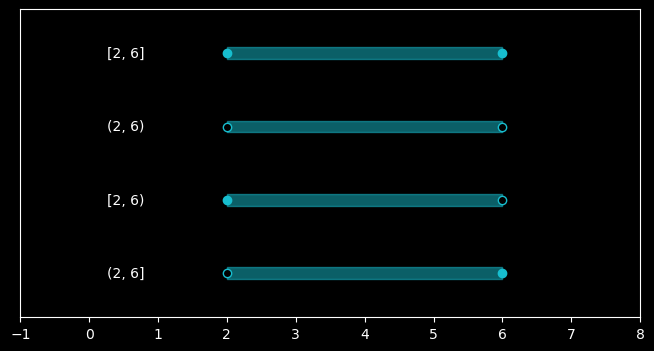

In [3]:
# A small helper to draw one interval. Filled dot = included, hollow = excluded.
# (Plotting mechanics only.)
def draw_interval(ax, a, b, left_closed, right_closed, y, label):
    x = np.linspace(a, b, 100)
    ax.fill_between(x, y - 0.08, y + 0.08, color="tab:cyan", alpha=0.5)
    ax.plot(a, y, "o", color="tab:cyan",
            markerfacecolor=("tab:cyan" if left_closed else "black"))   # left endpoint
    ax.plot(b, y, "o", color="tab:cyan",
            markerfacecolor=("tab:cyan" if right_closed else "black"))  # right endpoint
    ax.text(a - 1.2, y, label, ha="right", va="center")

fig, ax = plt.subplots(figsize=(8, 4))
draw_interval(ax, 2, 6, True,  True,  3, "[2, 6]")   # both included
draw_interval(ax, 2, 6, False, False, 2, "(2, 6)")   # both excluded
draw_interval(ax, 2, 6, True,  False, 1, "[2, 6)")   # left included
draw_interval(ax, 2, 6, False, True,  0, "(2, 6]")   # right included
ax.set_xlim(-1, 8)
ax.set_ylim(-0.6, 3.6)
ax.set_yticks([])
plt.show()

A filled dot means the endpoint is part of the set; a hollow dot means it is not. This is why $6 \in [2,6]$ but $6 \notin [2,6)$.

## 3. Unbounded intervals

An interval can run forever in one direction, written with $\infty$ or $-\infty$. Because infinity is not a number you can ever reach, it always takes a parenthesis. For example, $[18, \infty)$ means "all $x$ with $x \ge 18$" — everyone 18 or older.

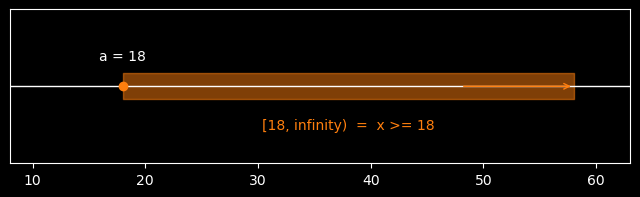

In [4]:
# "x >= 18" is the interval [18, infinity).
a = 18
x = np.linspace(a, a + 40, 100)

# --- graphics: a ray starting at a and running right (mechanics only) ---
fig, ax = plt.subplots(figsize=(8, 2))
ax.axhline(0, color="white", lw=1)
ax.fill_between(x, -0.15, 0.15, color="tab:orange", alpha=0.5)
ax.plot(a, 0, "o", color="tab:orange")            # closed at 18
ax.annotate("", xy=(a + 40, 0), xytext=(a + 30, 0),
            arrowprops=dict(arrowstyle="->", color="tab:orange"))
ax.text(a, 0.3, "a = 18", ha="center")
ax.text(a + 20, -0.5, "[18, infinity)  =  x >= 18", ha="center", color="tab:orange")
ax.set_xlim(a - 10, a + 45)
ax.set_ylim(-0.9, 0.9)
ax.set_yticks([])
plt.show()

## 4. Three equivalent notations

The same set of numbers can be written three ways — as an **inequality**, in **set-builder** notation, or in **interval** notation. All three below describe the numbers from 0 up to but *not* including 10:

$$0 \le x < 10 \qquad \{x : 0 \le x < 10\} \qquad [0, 10).$$

They are just different spellings of the same range. The code checks which numbers the inequality accepts.

In [5]:
# Check which numbers satisfy the inequality 0 <= x < 10.
test_values = [-1, 0, 5, 9, 10, 11]

for x in test_values:
    by_inequality = (0 <= x) and (x < 10)   # 0 <= x < 10
    print("x =", x, "| in [0, 10)?", by_inequality)

x = -1 | in [0, 10)? False
x = 0 | in [0, 10)? True
x = 5 | in [0, 10)? True
x = 9 | in [0, 10)? True
x = 10 | in [0, 10)? False
x = 11 | in [0, 10)? False


## 5. Combining intervals

Two intervals can be combined, just like any two sets. Their **intersection** is the overlap (numbers in *both*); their **union** is everything in *either*. We test each number against both intervals to see where it lands.

In [6]:
# Interval 1: [0, 6].  Interval 2: [4, 10].
def in_interval1(x):
    return 0 <= x <= 6

def in_interval2(x):
    return 4 <= x <= 10

test_values = [-1, 0, 4, 5, 6, 8, 10, 12]

print("value | in [0,6] | in [4,10] | intersection | union")
for x in test_values:
    a1 = in_interval1(x)
    a2 = in_interval2(x)
    print(f"{x:5d} |   {a1!s:5} |   {a2!s:5}   |   {a1 and a2!s:5}      | {a1 or a2}")

value | in [0,6] | in [4,10] | intersection | union
   -1 |   False |   False   |   False      | False
    0 |   True  |   False   |   False      | True
    4 |   True  |   True    |   True       | True
    5 |   True  |   True    |   True       | True
    6 |   True  |   True    |   True       | True
    8 |   False |   True    |   False      | True
   10 |   False |   True    |   False      | True
   12 |   False |   False   |   False      | False


The **intersection** of $[0,6]$ and $[4,10]$ is $[4,6]$ (only the overlap is in both), and their **union** is $[0,10]$ (everything either one covers).

## 6. Application: a normal lab range

Reference ranges in medicine are intervals. A measured value is "normal" if it lies inside the range — which is just an interval-membership test.

In [7]:
low = 70     # mg/dL
high = 100   # mg/dL

def is_normal(glucose):
    return low <= glucose <= high   # inside the closed interval [70, 100]

for value in [65, 70, 85, 100, 120]:
    print("glucose", value, "-> normal?", is_normal(value))

glucose 65 -> normal? False
glucose 70 -> normal? True
glucose 85 -> normal? True
glucose 100 -> normal? True
glucose 120 -> normal? False


## 7. Summary

- An **interval** is a continuous stretch of the real line; **brackets** include an endpoint, **parentheses** exclude it.
- **Unbounded** intervals use $\pm\infty$ (always with a parenthesis).
- The same set can be written as an **inequality**, in **set-builder**, or in **interval** notation.
- Intervals combine by **intersection** (overlap) and **union**; membership is a simple range test — exactly how a normal lab range works.

Next: **functions** — rules that turn an input into an output, and the intervals that say which
inputs are allowed (`U1-3_Functions-1_DomainRangeAndFamilies`).